# 4. Forecast next quarter's orders

**Approach**
1. Daily order counts from January 2017 (2016 is mostly test orders).
2. Hold out the last 91 days (one quarter) as a test set.
3. **Baseline: seasonal naive**, which repeats the last observed week. Any model has to beat this to be worth having.
4. **Model: SARIMA** on log daily orders with a weekly season. The candidate orders are compared by AIC on the training data only, so the test set isn't used to choose the model.
5. Compare on the hold-out with MAPE and MASE (MASE < 1 means better than a naive forecast *in-sample*).
6. Refit on everything and forecast the next quarter.

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root, for `analysis` and `common`

import itertools
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from analysis.forecast import SEASON, backtest, clean_daily_series, fit_sarima, sarima_forecast
from common.db import query

warnings.filterwarnings("ignore")
HORIZON = 91

2017-01-05 to 2018-08-21, 594 days


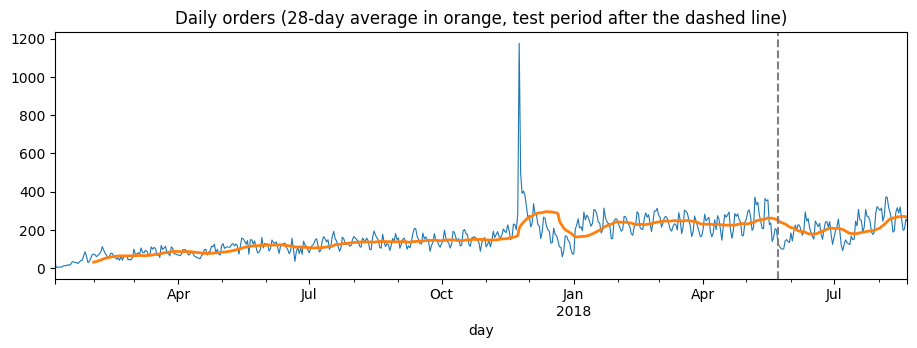

In [2]:
series = clean_daily_series(query("""
select purchase_date as day, count(*) as orders
from marts.fct_orders
where purchase_date >= '2017-01-01'
group by 1 order by 1
"""))
print(f"{series.index.min().date()} to {series.index.max().date()}, {len(series)} days")

fig, ax = plt.subplots(figsize=(11, 3.2))
series.plot(ax=ax, lw=0.8)
series.rolling(28).mean().plot(ax=ax, lw=2)
ax.axvline(series.index[-HORIZON], color="grey", ls="--")
ax.set_title("Daily orders (28-day average in orange, test period after the dashed line)")
plt.show()

## Pick the SARIMA order on the training data only

In [3]:
train = series.iloc[:-HORIZON]
candidates = []
for p, q, P, Q in itertools.product([0, 1, 2], [0, 1], [0, 1], [0, 1]):
    try:
        res = fit_sarima(train, order=(p, 1, q), seasonal_order=(P, 0, Q, SEASON))
        candidates.append({"order": (p, 1, q), "seasonal": (P, 0, Q, SEASON), "aic": res.aic})
    except Exception as exc:  # some combinations don't converge
        print("skipped", (p, q, P, Q), exc)

cands = pd.DataFrame(candidates).sort_values("aic")
best = cands.iloc[0]
print("chosen:", best["order"], best["seasonal"])
cands.head()

chosen: (2, 1, 1) (1, 0, 1, 7)


,order,seasonal,aic
23,"(2, 1, 1)","(1, 0, 1, 7)",-166.183250
7,"(0, 1, 1)","(1, 0, 1, 7)",-158.713199
15,"(1, 1, 1)","(1, 0, 1, 7)",-158.396252
19,"(2, 1, 0)","(1, 0, 1, 7)",-157.617276
11,"(1, 1, 0)","(1, 0, 1, 7)",-135.029043


## Hold-out comparison

In [4]:
bt = backtest(series, HORIZON, order=best["order"], seasonal_order=best["seasonal"])
bt.metrics.round(2)

,MAPE_daily_%,MASE_daily,total_forecast,total_actual,total_error_%
model,,,,,
seasonal naive,32.49,1.87,19838.00,19383.0,2.35
SARIMA,25.13,1.60,16784.26,19383.0,-13.41


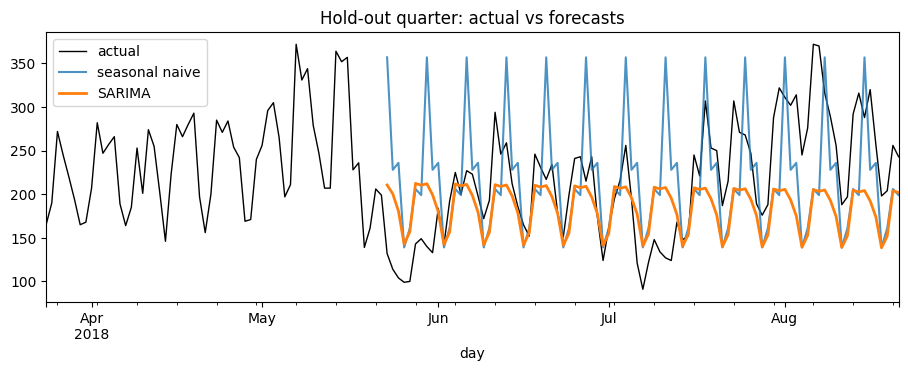

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.5))
series.iloc[-HORIZON - 60:].plot(ax=ax, color="black", lw=1, label="actual")
bt.naive.plot(ax=ax, label="seasonal naive", alpha=0.8)
bt.sarima.plot(ax=ax, label="SARIMA", lw=2)
ax.legend()
ax.set_title("Hold-out quarter: actual vs forecasts")
plt.show()

In [6]:
weekly = pd.DataFrame({"actual": bt.actual, "seasonal naive": bt.naive, "SARIMA": bt.sarima}).resample("W").sum()
weekly_mape = {m: (weekly[m] - weekly["actual"]).abs().div(weekly["actual"]).mean() * 100
               for m in ["seasonal naive", "SARIMA"]}
print("weekly MAPE:", {k: round(v, 1) for k, v in weekly_mape.items()})

weekly MAPE: {'seasonal naive': np.float64(24.9), 'SARIMA': np.float64(23.7)}


## Next quarter

forecast for 2018-08-22 to 2018-11-20
total orders: 27,660
(80% intervals are per day; they are not summed into a quarterly interval)


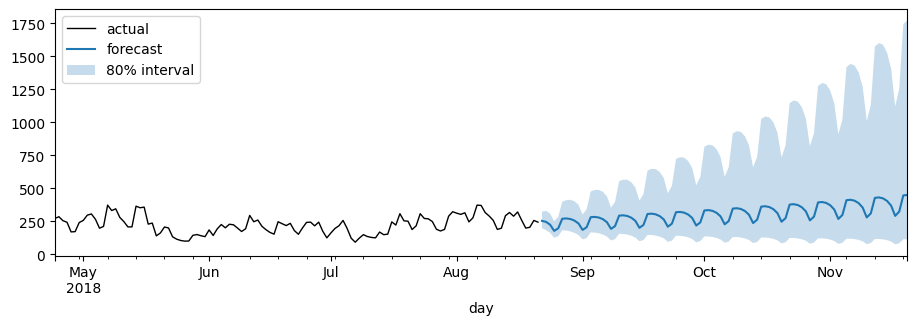

In [7]:
future = sarima_forecast(series, HORIZON, alpha=0.2, order=best["order"], seasonal_order=best["seasonal"])
print(f"forecast for {future.index[0].date()} to {future.index[-1].date()}")
print(f"total orders: {future['forecast'].sum():,.0f}")
print("(80% intervals are per day; they are not summed into a quarterly interval)")

fig, ax = plt.subplots(figsize=(11, 3.2))
series.iloc[-120:].plot(ax=ax, color="black", lw=1, label="actual")
future["forecast"].plot(ax=ax, label="forecast")
ax.fill_between(future.index, future["low"], future["high"], alpha=0.25, label="80% interval")
ax.legend()
plt.show()

## Limitations
- Only about 20 months of normal trading, so the model can't learn yearly seasonality: Black Friday and Christmas are not in the forecast. A quarter that includes November would need a holiday adjustment on top.
- The marketplace was still growing fast in 2017 and then flattened in 2018. A model fit over both periods is partly averaging two regimes.
- The data ends in 2018, so "next quarter" is a forecast of a period that has already happened but isn't in the dataset. The hold-out comparison is the honest measure of quality.

## What this means for the business

On the held-out quarter, SARIMA was more accurate day to day than the seasonal naive baseline (MAPE **25.1% vs 32.5%**, MASE 1.60 vs 1.87). It was worse on the quarter's total, though: **13% under** against 2% over for the baseline.

So use SARIMA for day-to-day planning such as warehouse staffing, but don't trust it over a simple baseline for the quarterly volume number. The refit model forecasts about **27,700 orders** for 22 Aug to 20 Nov 2018. That figure has no Black Friday effect, so a November plan needs a holiday uplift on top.